# Notebook 04 — CNN From Scratch

## Objectif
Construire un CNN (Convolutional Neural Network) from scratch — 
c'est-à-dire qu'on code nous-mêmes l'architecture couche par couche 
sans utiliser de modèle pré-entraîné.

Ce modèle montre qu'on maîtrise les briques de base vues en cours.

## Architecture
Input : image 224x224x3
→ Bloc 1 : Conv2D + BatchNorm + ReLU + MaxPooling
→ Bloc 2 : Conv2D + BatchNorm + ReLU + MaxPooling  
→ Bloc 3 : Conv2D + BatchNorm + ReLU + MaxPooling
→ Flatten
→ Dropout
→ Dense 256
→ Dense 4 (sortie — 4 niveaux de sévérité)

Image 224x224x3
      ↓
[Conv2D 32 filtres] → détecte contours
[BatchNorm]         → stabilise
[ReLU]              → non-linéarité  
[MaxPooling]        → réduit → 112x112x32
      ↓
[Conv2D 64 filtres] → détecte formes
[BatchNorm]         
[ReLU]              
[MaxPooling]        → réduit → 56x56x64
      ↓
[Conv2D 128 filtres] → détecte lésions
[BatchNorm]          
[ReLU]               
[MaxPooling]         → réduit → 28x28x128
      ↓
[Flatten]           → 100 352 valeurs
[Dropout 50%]       → réduit overfitting
[Dense 256]         → combine features
[Dense 4]           → 4 niveaux
[Softmax]           → probabilités
      ↓
Prédiction : niveau 0, 1, 2 ou 3

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Vérifier si GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")

Device utilisé : cpu


In [2]:
# Classe Dataset PyTorch
class AcneDataset(Dataset):
    def __init__(self, csv_path, images_path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.images_path = images_path
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Charger l'image
        nom_image = self.df.iloc[idx]["image"]
        niveau = self.df.iloc[idx]["niveau"]
        chemin = os.path.join(self.images_path, nom_image)
        image = Image.open(chemin).convert("RGB")
        
        # Appliquer les transformations
        if self.transform:
            image = self.transform(image)
        
        return image, niveau

print("Classe AcneDataset définie ✓")

Classe AcneDataset définie ✓


In [3]:
# Chemins
IMAGES_PATH = "../data/images_preprocessees"
TRAIN_CSV = "../data/splits/train.csv"
VAL_CSV = "../data/splits/val.csv"
TEST_CSV = "../data/splits/test.csv"

# Transforms pour le TRAIN (avec augmentation)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Transforms pour VAL et TEST (sans augmentation)
transform_val_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Datasets
train_dataset = AcneDataset(TRAIN_CSV, IMAGES_PATH, transform=transform_train)
val_dataset   = AcneDataset(VAL_CSV, IMAGES_PATH, transform=transform_val_test)
test_dataset  = AcneDataset(TEST_CSV, IMAGES_PATH, transform=transform_val_test)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train : {len(train_dataset)} images")
print(f"Val   : {len(val_dataset)} images")
print(f"Test  : {len(test_dataset)} images")

Train : 975 images
Val   : 209 images
Test  : 210 images


In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # Bloc 1
        self.bloc1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Bloc 2
        self.bloc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Bloc 3
        self.bloc3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Classificateur final
        self.classificateur = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 4)
        )
    
    def forward(self, x):
        x = self.bloc1(x)
        x = self.bloc2(x)
        x = self.bloc3(x)
        x = self.classificateur(x)
        return x

# Tester
modele = CNN().to(device)
print(modele)
print(f"\nNombre de paramètres : {sum(p.numel() for p in modele.parameters()):,}")

CNN(
  (bloc1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloc3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classificateur): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2):

In [5]:
# Définir la loss et l'optimiseur
criterion = nn.CrossEntropyLoss()
optimiseur = optim.Adam(modele.parameters(), lr=0.001)

# Boucle d'entraînement
def entrainer(modele, train_loader, val_loader, criterion, optimiseur, nb_epoques=20):
    
    historique = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    
    for epoque in range(nb_epoques):
        
        # --- TRAIN ---
        modele.train()
        train_loss = 0
        train_correct = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimiseur.zero_grad()        # remettre les gradients à zéro
            sorties = modele(images)      # forward pass
            loss = criterion(sorties, labels)  # calculer la loss
            loss.backward()               # backpropagation
            optimiseur.step()             # mettre à jour les poids
            
            train_loss += loss.item()
            train_correct += (sorties.argmax(1) == labels).sum().item()
        
        # --- VALIDATION ---
        modele.eval()
        val_loss = 0
        val_correct = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                sorties = modele(images)
                loss = criterion(sorties, labels)
                val_loss += loss.item()
                val_correct += (sorties.argmax(1) == labels).sum().item()
        
        # Calculer les métriques
        train_acc = train_correct / len(train_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)
        train_loss = train_loss / len(train_loader)
        val_loss = val_loss / len(val_loader)
        
        historique["train_loss"].append(train_loss)
        historique["val_loss"].append(val_loss)
        historique["train_acc"].append(train_acc)
        historique["val_acc"].append(val_acc)
        
        print(f"Époque {epoque+1}/{nb_epoques} | "
              f"Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.3f} | "
              f"Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.3f}")
    
    return historique

# Lancer l'entraînement
historique = entrainer(modele, train_loader, val_loader, criterion, optimiseur, nb_epoques=20)

Époque 1/20 | Train Loss: 14.493 | Train Acc: 0.361 | Val Loss: 1.619 | Val Acc: 0.402
Époque 2/20 | Train Loss: 1.388 | Train Acc: 0.427 | Val Loss: 1.618 | Val Acc: 0.459
Époque 3/20 | Train Loss: 1.239 | Train Acc: 0.447 | Val Loss: 1.186 | Val Acc: 0.426
Époque 4/20 | Train Loss: 1.244 | Train Acc: 0.411 | Val Loss: 1.138 | Val Acc: 0.402
Époque 5/20 | Train Loss: 1.164 | Train Acc: 0.462 | Val Loss: 1.310 | Val Acc: 0.459
Époque 6/20 | Train Loss: 1.103 | Train Acc: 0.491 | Val Loss: 1.092 | Val Acc: 0.435
Époque 7/20 | Train Loss: 1.054 | Train Acc: 0.474 | Val Loss: 1.064 | Val Acc: 0.440
Époque 8/20 | Train Loss: 1.039 | Train Acc: 0.521 | Val Loss: 1.093 | Val Acc: 0.402
Époque 9/20 | Train Loss: 1.047 | Train Acc: 0.480 | Val Loss: 1.079 | Val Acc: 0.474
Époque 10/20 | Train Loss: 1.001 | Train Acc: 0.514 | Val Loss: 1.061 | Val Acc: 0.421
Époque 11/20 | Train Loss: 1.016 | Train Acc: 0.498 | Val Loss: 1.048 | Val Acc: 0.469
Époque 12/20 | Train Loss: 0.994 | Train Acc: 0.526

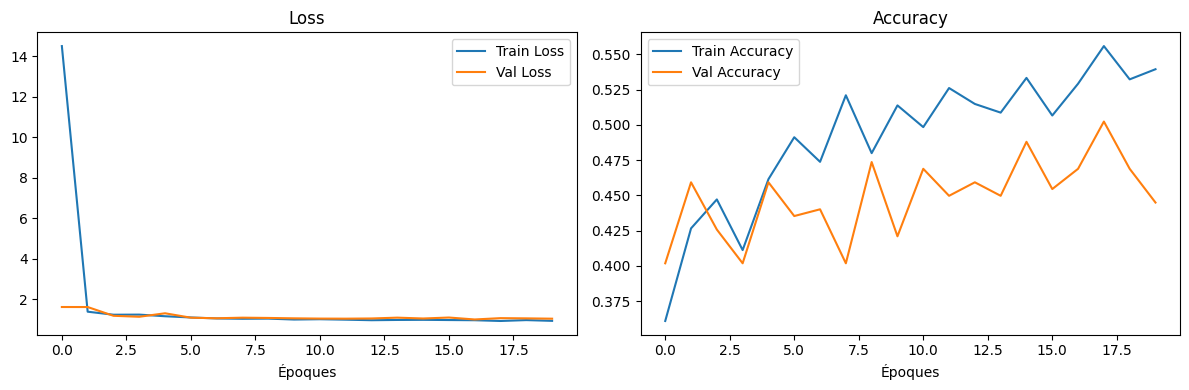

In [6]:
# Courbes d'apprentissage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historique["train_loss"], label="Train Loss")
ax1.plot(historique["val_loss"], label="Val Loss")
ax1.set_title("Loss")
ax1.set_xlabel("Époques")
ax1.legend()

ax2.plot(historique["train_acc"], label="Train Accuracy")
ax2.plot(historique["val_acc"], label="Val Accuracy")
ax2.set_title("Accuracy")
ax2.set_xlabel("Époques")
ax2.legend()

plt.tight_layout()
plt.show()

=== CNN Scratch — Résultats finaux ===
Accuracy : 0.481
F1-Score : 0.344


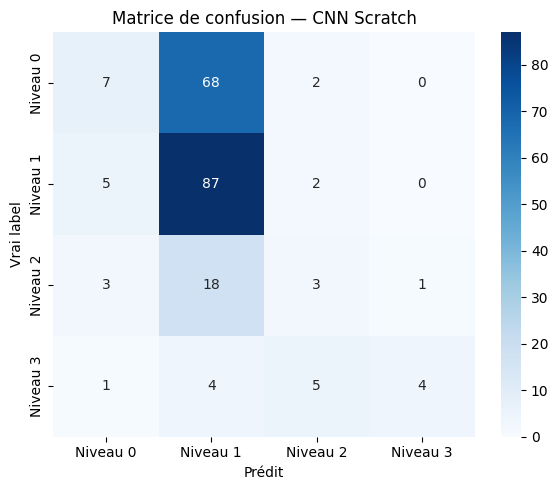

In [9]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

# Evaluation sur le test set
modele.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        sorties = modele(images)
        predictions = sorties.argmax(1).cpu().numpy()
        y_pred.extend(predictions)
        y_true.extend(labels.numpy())

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="macro")

print(f"=== CNN Scratch — Résultats finaux ===")
print(f"Accuracy : {acc:.3f}")
print(f"F1-Score : {f1:.3f}")

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Niveau 0", "Niveau 1", "Niveau 2", "Niveau 3"],
            yticklabels=["Niveau 0", "Niveau 1", "Niveau 2", "Niveau 3"])
plt.title("Matrice de confusion — CNN Scratch")
plt.ylabel("Vrai label")
plt.xlabel("Prédit")
plt.tight_layout()
plt.savefig("../results/figures/matrice_cnn.png", dpi=150, bbox_inches='tight')
plt.show()

Le CNN from scratch améliore légèrement la détection des cas sévères par rapport au KNN, mais reste limité par la taille du dataset. Le transfer learning avec EfficientNet devrait apporter une amélioration significative.